# Exploratory Data Analysis

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression


### Problem Definition
This analysis aims to explore how different factors — such as location, room type, and host activity — influence Airbnb rental prices in New York City in 2019.

In [2]:
#Import the data and create dataframe
df = pd.read_csv("/workspaces/crerov-intro-machine-learning/data/AB_NYC_2019.csv")
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [9]:
#Check the shape
df.shape

(48895, 16)

In [10]:
#Find more info on the df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [11]:
#Find statistical information on the df, and transpose it
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


I find 8 cathegorical characteristics and 8 numerical characteristics

Both last_review and reviews_per_month columns have a lot of NaN values.


### Data cleaning

In [12]:
# Drop columns with missing colums or not relevant to price investigation
df.drop(["last_review", "reviews_per_month", "id", "name", "host_id", "host_name", "latitude", "longitude" ], axis = 1, inplace = True)
df

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,Private room,149,1,9,6,365
1,Manhattan,Midtown,Entire home/apt,225,1,45,2,355
2,Manhattan,Harlem,Private room,150,3,0,1,365
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,Entire home/apt,80,10,9,1,0
...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,Private room,70,2,0,2,9
48891,Brooklyn,Bushwick,Private room,40,4,0,2,36
48892,Manhattan,Harlem,Entire home/apt,115,10,0,1,27
48893,Manhattan,Hell's Kitchen,Shared room,55,1,0,6,2


I have dropped variables that did not give me information relevant to predicting price, and those that were redundant.

### Visualization (univariate)

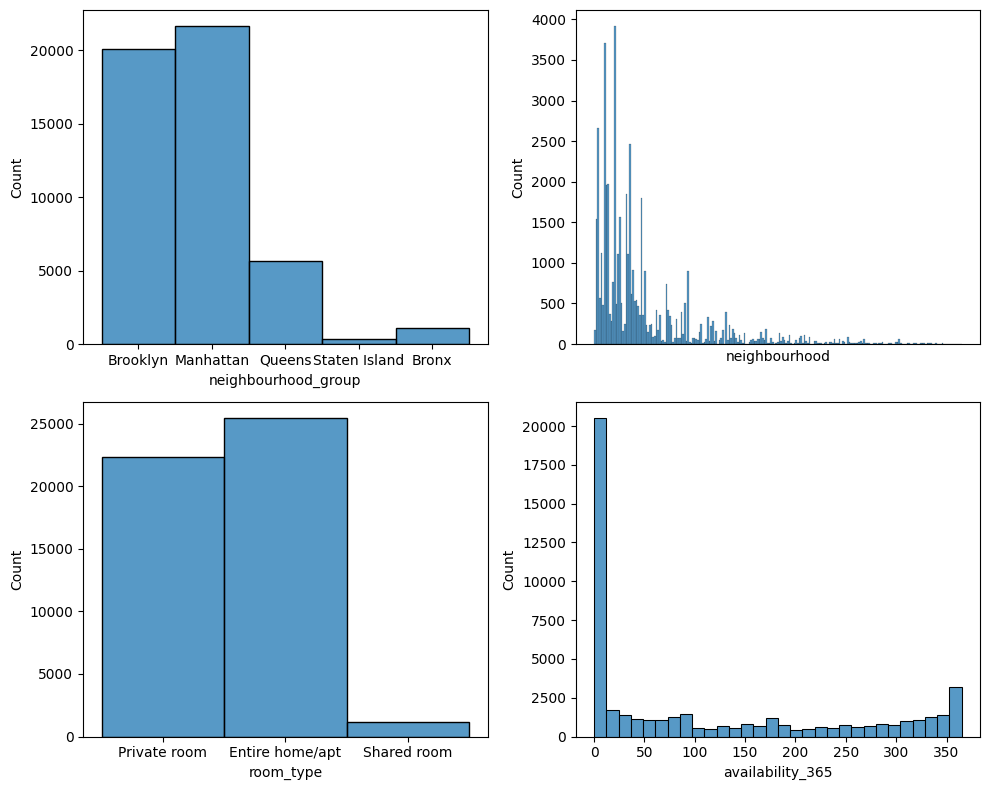

In [23]:
# visualizing cathecorigal features with a histogram

fig, axis = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(ax = axis[0,0], data = df, x = "neighbourhood_group")
sns.histplot(ax = axis[0,1], data = df, x = "neighbourhood").set_xticks([])
sns.histplot(ax = axis[1,0], data = df, x = "room_type")
sns.histplot(ax = axis[1,1], data = df, x = "availability_365")


# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()




- I see most options are located in Brooklyn and Manhattan, and the least in Staten Island
- The offer in different neighborhoods is massively different
- The most common room types are whole apartments and private rooms, with barely any shared rooms
- The majority of the rooms are available 365 days per year, but in our dataset, there's a lot of 0 / NaN for this category, which has to be a mistake/lack of information.

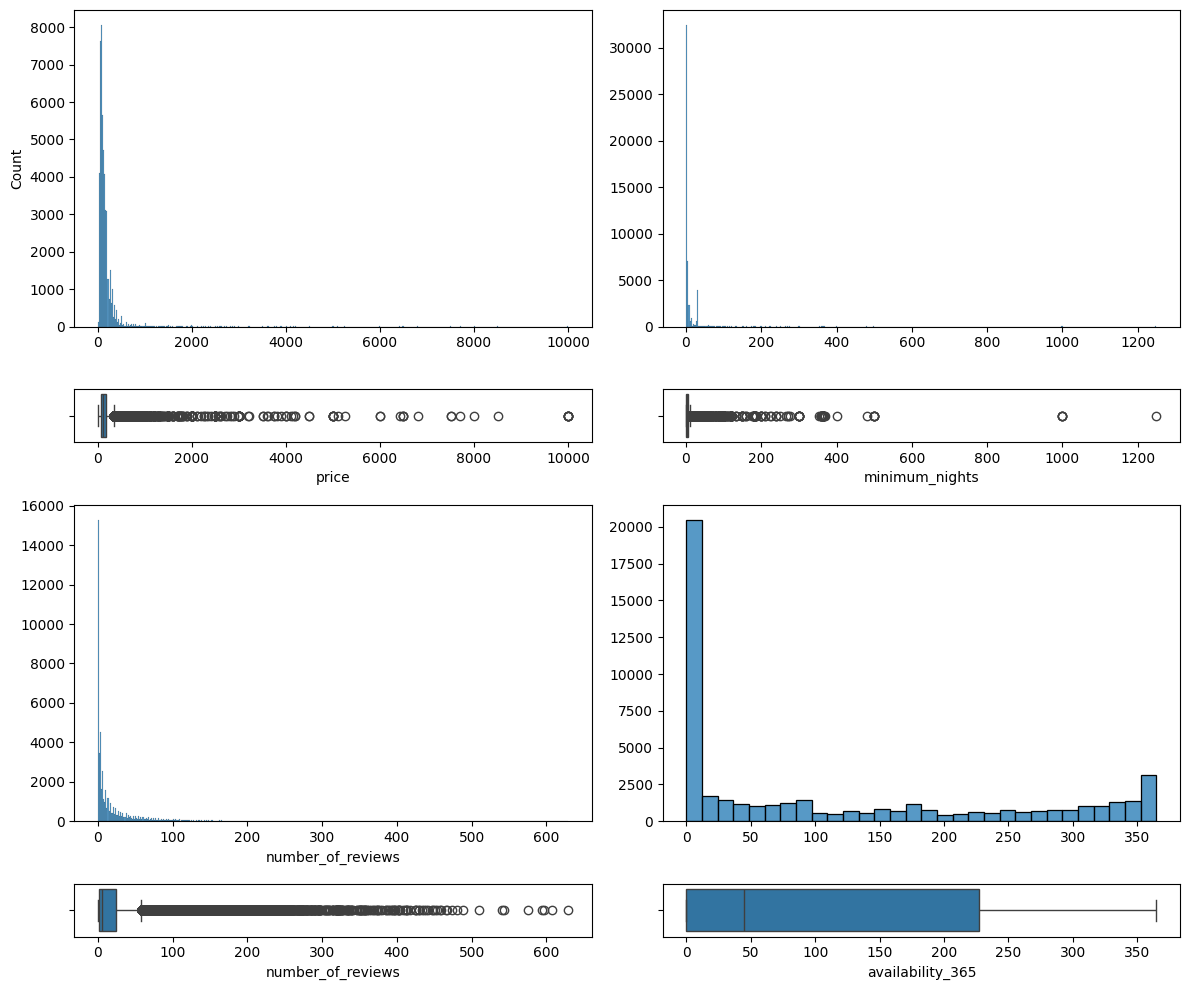

In [25]:
# Visualizing numeric variables

fig, axis = plt.subplots(4, 2, figsize = (12, 10), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

# Creating a multiple-plot figure with histograms and boxplots
sns.histplot(ax = axis[0,0], data = df, x = "price").set(xlabel = None)
sns.boxplot(ax = axis[1,0], data = df, x = "price")

sns.histplot(ax = axis[0,1], data = df, x = "minimum_nights").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1,1], data = df, x = "minimum_nights")

sns.histplot(ax = axis[2,0], data = df, x = "number_of_reviews").set(ylabel = None)
sns.boxplot(ax = axis[3,0], data = df, x = "number_of_reviews")

sns.histplot(ax = axis[2,1], data = df, x = "availability_365").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3,1], data = df, x = "availability_365")

plt.tight_layout()
plt.show()

Most accommodation prices are low, but there are a few outliers (maybe luxury accomodations).
Most listings have a very small minimum stay (1 or a few nights), but there are some extreme cases with very long minimum stays.
Leaving reviews is uncommon.
Avaliability distribution data doesn't allow for conclussions

### Visualization (multivariate)

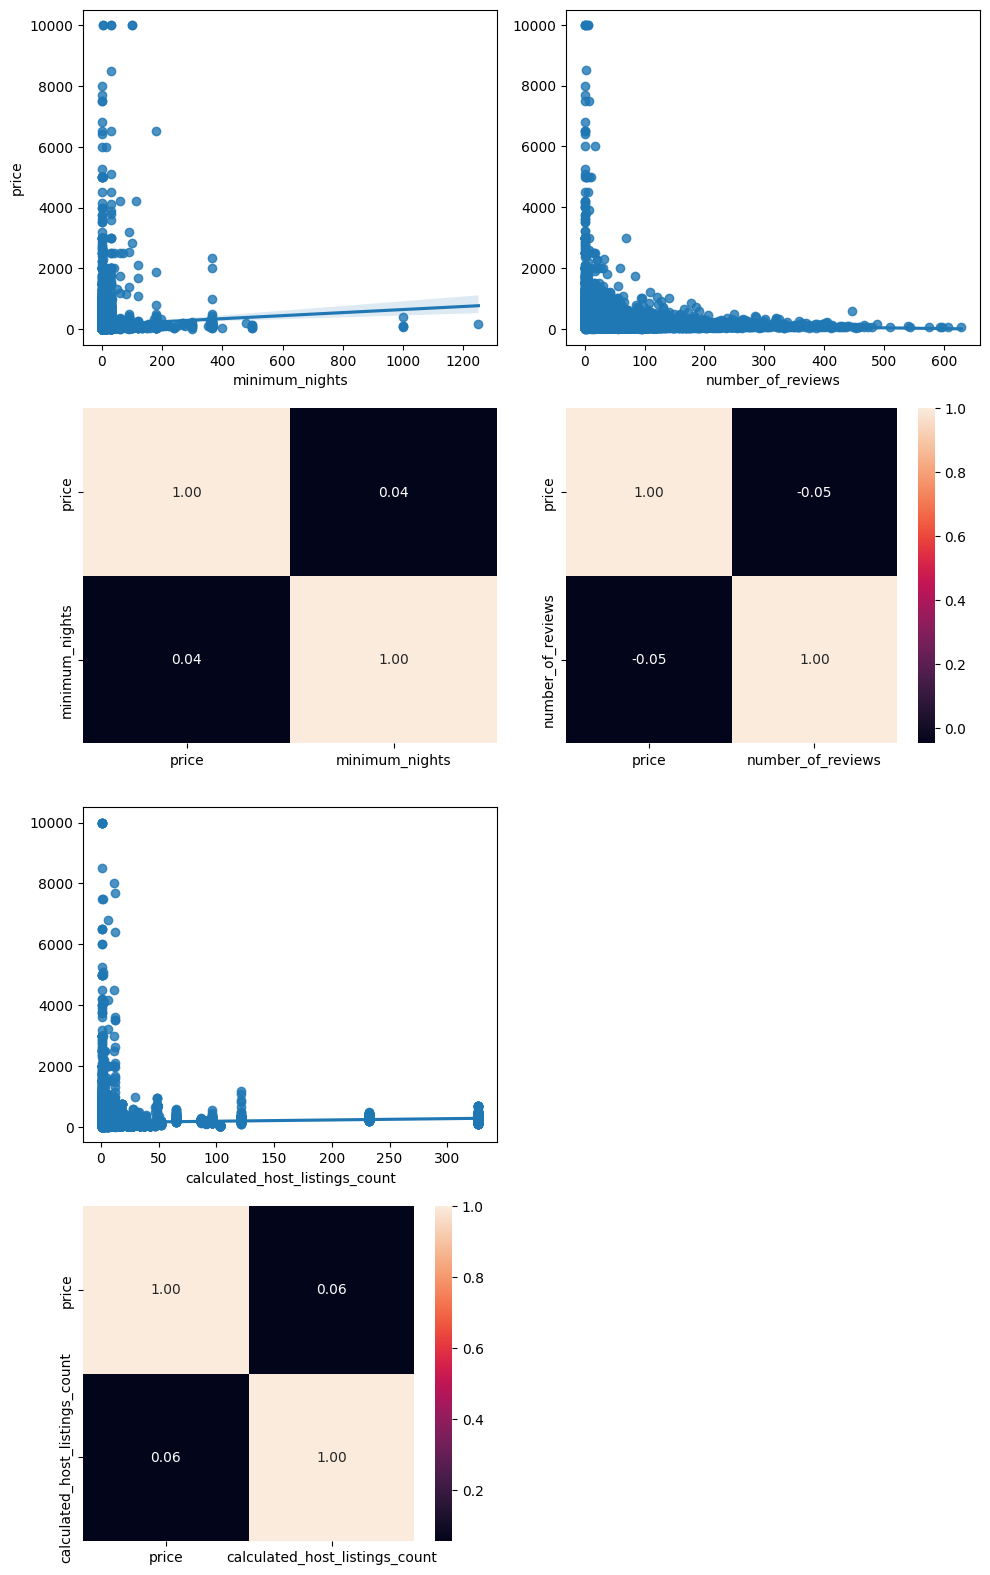

In [27]:
# Numerical analysis

fig, axis = plt.subplots(4, 2, figsize = (10, 16))


sns.regplot(ax = axis[0, 0], data = df, x = "minimum_nights", y = "price")
sns.heatmap(df[["price", "minimum_nights"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df, x = "number_of_reviews", y = "price").set(ylabel = None)
sns.heatmap(df[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = df, x = "calculated_host_listings_count", y = "price").set(ylabel = None)
sns.heatmap(df[["price", "calculated_host_listings_count"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0]).set(ylabel = None)
fig.delaxes(axis[2, 1])
fig.delaxes(axis[3, 1])

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()



I find no relation between the price and minimum number of nights, or between the reviews and the price.
You can see this in the heatmaps, which displays a correlation very close to 0 in all cases.

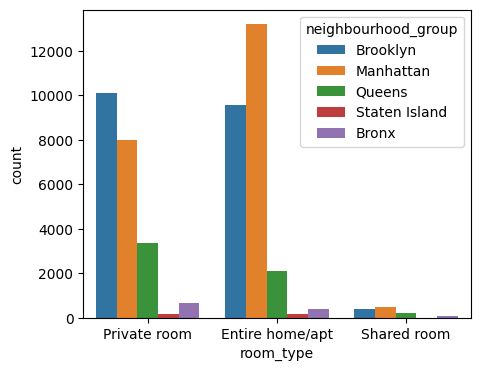

In [29]:
#Categorical relations
fig, axis = plt.subplots(figsize = (5, 4))

sns.countplot(data = df, x = "room_type", hue = "neighbourhood_group")

# Show the plot
plt.show()

There is no big relationship between meighbourhood group and room type, but: 
- Manhattan is the place with more places to rent, and the one with more Entire/Homes to rent.
- Brooklyn is the 2nd biggest group to rent, but has more Private Rooms, meaning probably more people sharing their home.

### Train/ test split

In [32]:
# Define X (features) and y (target)
X = df.drop(columns = ["price"])
y = df["price"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### One Hot Encoding

In [33]:
# Categorical columns
cat_columns = ["neighbourhood_group", "room_type"]
encoder = OneHotEncoder(sparse_output = False)

X_train_encoded = encoder.fit_transform(X_train[cat_columns])
X_test_encoded = encoder.transform(X_test[cat_columns])

X_train_one_hot = pd.DataFrame(X_train_encoded, columns = encoder.get_feature_names_out(cat_columns), index = X_train.index)
X_test_one_hot = pd.DataFrame(X_test_encoded, columns = encoder.get_feature_names_out(cat_columns), index = X_test.index)

X_train_final = pd.concat([X_train.drop(columns=cat_columns), X_train_one_hot], axis = 1)
X_test_final  = pd.concat([X_test.drop(columns=cat_columns), X_test_one_hot], axis = 1)

In [34]:
X_train_final.head()

,neighbourhood,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
32645,Williamsburg,3,11,1,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
23615,Washington Heights,2,2,1,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
31183,Bedford-Stuyvesant,2,0,2,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
29260,Bedford-Stuyvesant,3,87,1,267,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7275,Woodside,5,13,1,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


### Scaling

In [35]:
# Select numeric columns + encoded columns
columns_to_scale = ["minimum_nights", "number_of_reviews", "calculated_host_listings_count", "availability_365"] + [col for col in X_train_final.columns if col.startswith("neighbourhood_group_") or col.startswith("room_type_")]

# Standard Scaler
scaler = StandardScaler()
scaler.fit(X_train_final[columns_to_scale])
X_train_scaled = scaler.transform(X_train_final[columns_to_scale])
X_test_scaled  = scaler.transform(X_test_final[columns_to_scale])

# Convert to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = columns_to_scale, index = X_train_final.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled, columns = columns_to_scale, index = X_test_final.index)

X_train_scaled_df.head()

,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
32645,-0.193025,-0.277198,-0.186570,-0.852862,-0.15029,1.195897,-0.894201,-0.359737,-0.087023,0.958818,-0.914614,-0.155111
23615,-0.239596,-0.479451,-0.186570,-0.860447,-0.15029,-0.836193,1.118317,-0.359737,-0.087023,-1.042950,1.093358,-0.155111
31183,-0.239596,-0.524396,-0.156424,-0.860447,-0.15029,1.195897,-0.894201,-0.359737,-0.087023,-1.042950,1.093358,-0.155111
29260,-0.193025,1.430714,-0.186570,1.164663,-0.15029,1.195897,-0.894201,-0.359737,-0.087023,0.958818,-0.914614,-0.155111
7275,-0.099884,-0.232253,-0.186570,-0.860447,-0.15029,-0.836193,-0.894201,2.779812,-0.087023,-1.042950,1.093358,-0.155111


### Save processed data

In [38]:
# Save the processed training and testing datasets as CSV files
X_train_scaled_df.to_csv("/workspaces/crerov-intro-machine-learning/data/processed/X_train_sel.csv", index = False)
X_test_scaled_df.to_csv("/workspaces/crerov-intro-machine-learning/data/processed/X_test_sel.csv", index = False)
y_train.to_csv("/workspaces/crerov-intro-machine-learning/data/processed/y_train_sel.csv", index = False)
y_test.to_csv("/workspaces/crerov-intro-machine-learning/data/processed/y_test_sel.csv", index = False)